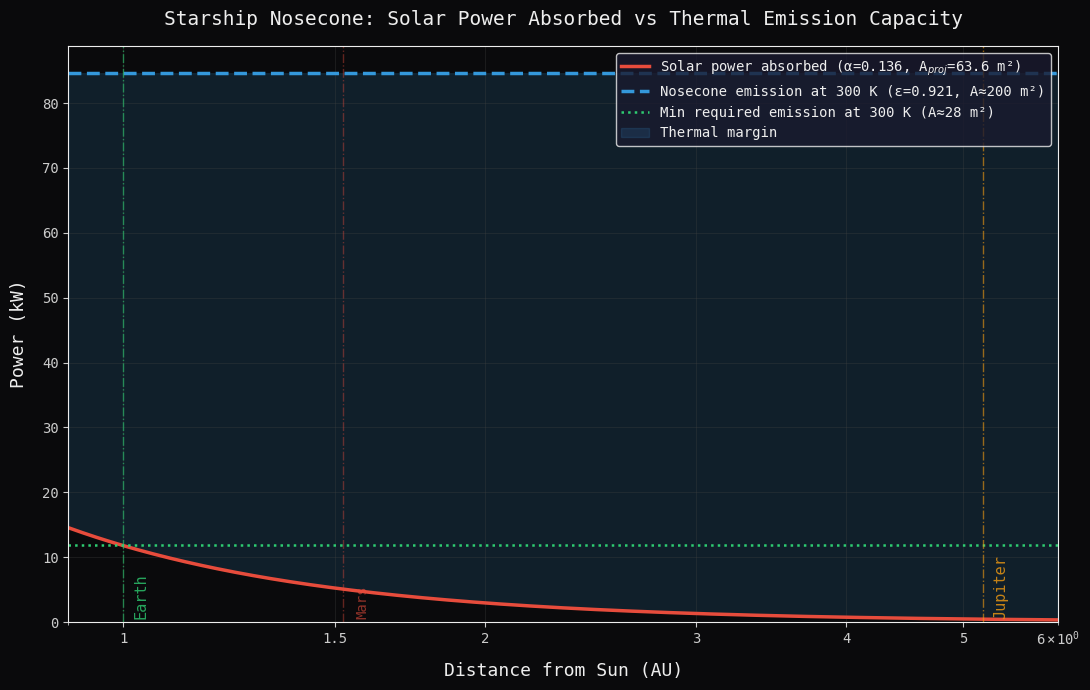

P_abs at Earth (1 AU):   11.78 kW
P_abs at Jupiter (5.2 AU): 0.44 kW
P_emit (nosecone, 300K):   84.60 kW
P_emit (min area, 300K):   11.84 kW


In [5]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor': '#0A0A0C',
    'axes.facecolor':   '#0A0A0C',
    'axes.edgecolor':   '#EEEEEE',
    'axes.labelcolor':  '#EEEEEE',
    'text.color':       '#EEEEEE',
    'xtick.color':      '#CCCCCC',
    'ytick.color':      '#CCCCCC',
    'grid.color':       '#444444',
    'font.family':      'monospace',
    'axes.titlepad':    15,
})

# --- Physical constants & Starship parameters (from paper) ---
sigma = 5.670374419e-8   # Stefan-Boltzmann constant, W m^-2 K^-4
S0    = 1361.0            # Solar irradiance at 1 AU, W/m^2
alpha = 0.136             # Solar absorptance, Z-93P white paint
eps   = 0.921             # Thermal emittance, Z-93P
D     = 9.0               # Starship diameter, m
T_fwd = 300.0             # Forward section equilibrium temperature, K

A_proj = np.pi * (D / 2)**2  # Projected cross-section absorbing sunlight, m^2

# Nosecone radiating area estimate:
# The Starship nosecone is an ogive ~18 m tall, 9 m base diameter.
# Approximate as a cone: slant height ≈ sqrt(18^2 + 4.5^2) ≈ 18.6 m
# Lateral area = pi * r * slant ≈ 263 m^2.
# Conservatively take ~200 m^2 (not all surface has clear view to space).
A_nosecone = 200.0  # m^2, effective radiating area of forward section

# --- Distance range: 1 AU (Earth) to 5.2 AU (Jupiter), logarithmic ---
r_au = np.logspace(np.log10(0.9), np.log10(6.0), 500)  # AU

# --- Radiation IN: absorbed solar power through nosecone ---
P_abs = alpha * S0 * A_proj / r_au**2  # W

# --- Radiation OUT: thermal emission from nosecone at 300 K ---
P_emit = eps * sigma * A_nosecone * T_fwd**4  # W, constant

# --- Also show the minimum required area (28 m^2) emission for reference ---
A_min = 28.0  # m^2, from paper
P_emit_min = eps * sigma * A_min * T_fwd**4  # W

# --- Plot ---
fig, ax = plt.subplots(figsize=(11, 7))

ax.plot(r_au, P_abs / 1e3, color='#e74c3c', linewidth=2.5,
        label=f'Solar power absorbed (α={alpha}, A$_{{proj}}$={A_proj:.1f} m²)')
ax.axhline(P_emit / 1e3, color='#3498db', linewidth=2.5, linestyle='--',
           label=f'Nosecone emission at {T_fwd:.0f} K (ε={eps}, A≈{A_nosecone:.0f} m²)')
ax.axhline(P_emit_min / 1e3, color='#2ecc71', linewidth=1.8, linestyle=':',
           label=f'Min required emission at {T_fwd:.0f} K (A≈{A_min:.0f} m²)')

# Fill the margin region
ax.fill_between(r_au, P_abs / 1e3, P_emit / 1e3,
                where=(P_abs / 1e3 < P_emit / 1e3),
                alpha=0.15, color='#3498db', label='Thermal margin')

# Annotate Earth and Jupiter
ax.axvline(1.0, color='#2ecc71', linewidth=1, linestyle='-.', alpha=0.6)
ax.text(1.02, ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else 0.5, 'Earth',
        color='#2ecc71', fontsize=11, va='bottom', rotation=90, alpha=0.8)

ax.axvline(5.2, color='#f39c12', linewidth=1, linestyle='-.', alpha=0.6)
ax.text(5.3, 0.5, 'Jupiter', color='#f39c12', fontsize=11, va='bottom',
        rotation=90, alpha=0.8)

# Mars for context
ax.axvline(1.524, color='#e74c3c', linewidth=1, linestyle='-.', alpha=0.4)
ax.text(1.56, 0.5, 'Mars', color='#e74c3c', fontsize=10, va='bottom',
        rotation=90, alpha=0.6)

ax.set_xscale('log')
ax.set_xlabel('Distance from Sun (AU)', fontsize=13, labelpad=10)
ax.set_ylabel('Power (kW)', fontsize=13, labelpad=10)
ax.set_title('Starship Nosecone: Solar Power Absorbed vs Thermal Emission Capacity',
             fontsize=14, pad=15)

ax.set_xlim(0.9, 6.0)
ax.set_ylim(bottom=0)

# Custom log ticks
ax.set_xticks([1, 1.5, 2, 3, 4, 5])
ax.set_xticklabels(['1', '1.5', '2', '3', '4', '5'])

ax.legend(loc='upper right', fontsize=10, facecolor='#1a1a2e', edgecolor='#EEEEEE')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"P_abs at Earth (1 AU):   {alpha * S0 * A_proj / 1e3:.2f} kW")
print(f"P_abs at Jupiter (5.2 AU): {alpha * S0 * A_proj / 5.2**2 / 1e3:.2f} kW")
print(f"P_emit (nosecone, 300K):   {P_emit / 1e3:.2f} kW")
print(f"P_emit (min area, 300K):   {P_emit_min / 1e3:.2f} kW")

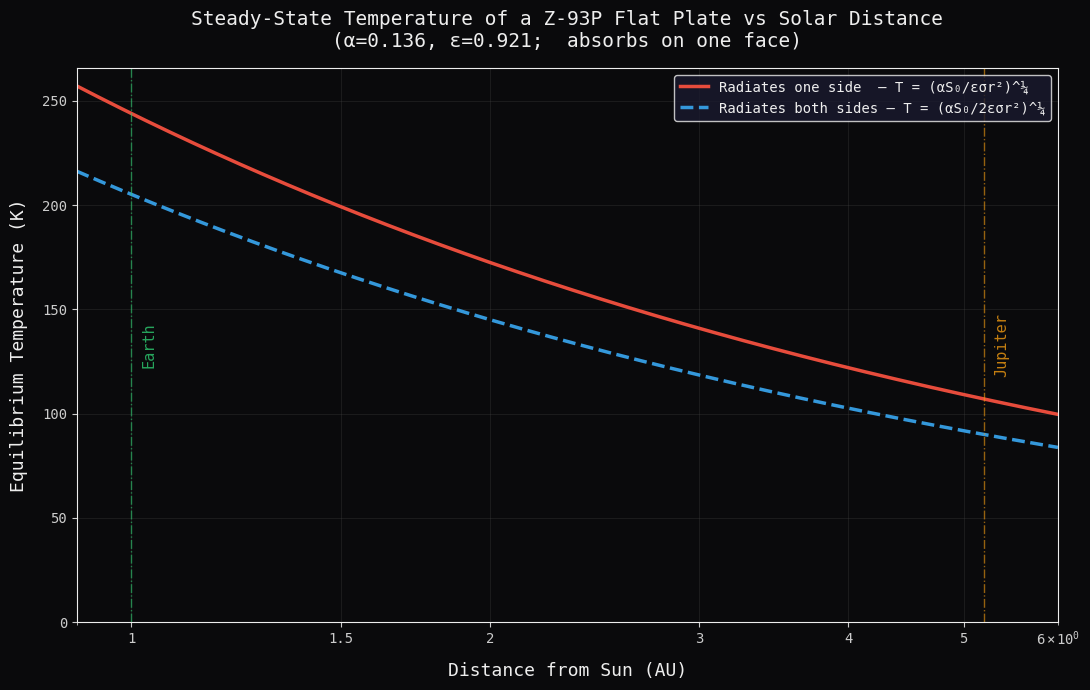

Earth  (1.0 AU):  one-side 244.0 K   both-sides 205.2 K   ratio 1.1892
Mars   (1.5 AU):  one-side 197.6 K   both-sides 166.2 K   ratio 1.1892
Jupiter(5.2 AU):  one-side 107.0 K   both-sides 90.0 K   ratio 1.1892


In [18]:
# Steady-state temperature of a flat 2D Z-93P object vs distance from the Sun.
#
# Case 1 — radiates from ONE side:
#   α·S₀·A / r² = ε·σ·A·T⁴  →  T = (α·S₀ / (ε·σ·r²))^(1/4)
#
# Case 2 — radiates from BOTH sides:
#   α·S₀·A / r² = ε·σ·2A·T⁴  →  T = (α·S₀ / (2·ε·σ·r²))^(1/4)

sigma = 5.670374419e-8   # Stefan-Boltzmann constant, W m^-2 K^-4
S0    = 1361.0            # Solar irradiance at 1 AU, W/m^2
alpha = 0.136             # Solar absorptance, Z-93P white paint
eps   = 0.921             # Thermal emittance, Z-93P
D     = 9.0               # Starship diameter, m
T_fwd = 300.0             # Forward section equilibrium temperature, K

r_au = np.logspace(np.log10(0.9), np.log10(6.0), 500)

T_one_side  = (alpha * S0 / (1 * eps * sigma * r_au**2))**0.25
T_both_side = (alpha * S0 / (2 * eps * sigma * r_au**2))**0.25

fig, ax = plt.subplots(figsize=(11, 7))

ax.plot(r_au, T_one_side,  color='#e74c3c', linewidth=2.5,
        label=f'Radiates one side  — T = (αS₀/εσr²)^¼')
ax.plot(r_au, T_both_side, color='#3498db', linewidth=2.5, linestyle='--',
        label=f'Radiates both sides — T = (αS₀/2εσr²)^¼')

# Planet markers
for x, lbl, c in [(1.0, 'Earth', '#2ecc71'), (5.2, 'Jupiter', '#f39c12')]:
    ax.axvline(x, color=c, linewidth=1, linestyle='-.', alpha=0.6)
    ax.text(x * 1.02, 0.5, lbl, color=c, fontsize=11, va='center', rotation=90,
            alpha=0.8, transform=ax.get_xaxis_transform())

ax.set_xscale('log')
ax.set_xlabel('Distance from Sun (AU)', fontsize=13, labelpad=10)
ax.set_ylabel('Equilibrium Temperature (K)', fontsize=13, labelpad=10)
ax.set_title('Steady-State Temperature of a Z-93P Flat Plate vs Solar Distance\n'
             f'(α={alpha}, ε={eps};  absorbs on one face)', fontsize=14, pad=15)

ax.set_xlim(0.9, 6.0)
ax.set_ylim(bottom=0)
ax.set_xticks([1, 1.5, 2, 3, 4, 5])
ax.set_xticklabels(['1', '1.5', '2', '3', '4', '5'])

ax.legend(loc='upper right', fontsize=10, facecolor='#1a1a2e', edgecolor='#EEEEEE')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

for r, lbl in [(1.0, 'Earth  (1.0 AU)'), (1.524, 'Mars   (1.5 AU)'), (5.2, 'Jupiter(5.2 AU)')]:
    t1 = (alpha * S0 / (1 * eps * sigma * r**2))**0.25
    t2 = (alpha * S0 / (2 * eps * sigma * r**2))**0.25
    print(f"{lbl}:  one-side {t1:.1f} K   both-sides {t2:.1f} K   ratio {t1/t2:.4f}")

Solver: converged (5977 nodes)


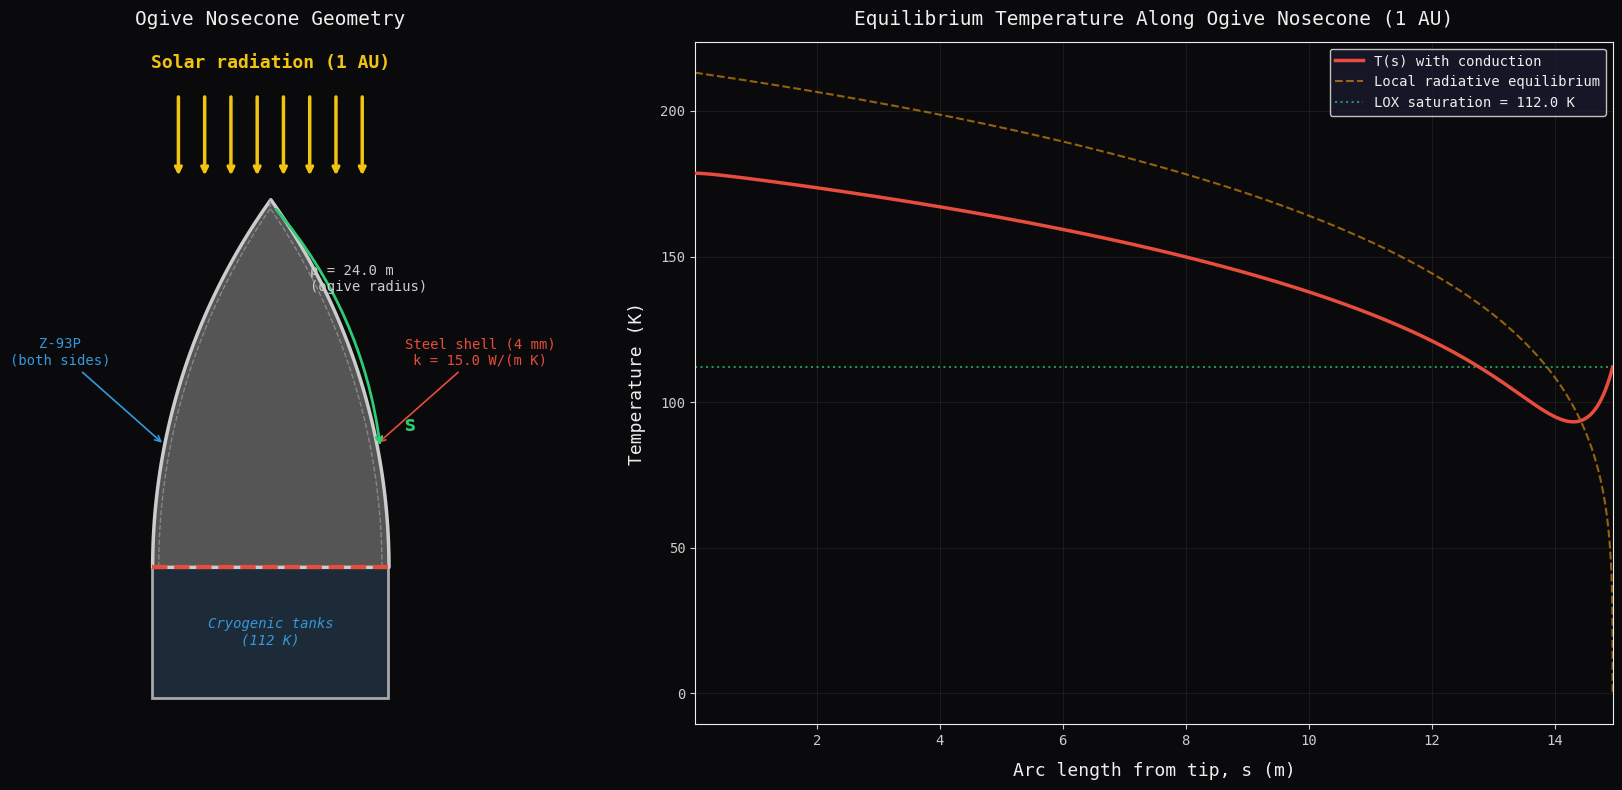


Ogive: ρ = 24.03 m,  arc length = 14.95 m
Tip temperature:  178.6 K  (local eq: 213.1 K)
Mid temperature (s=7.5 m):  152.6 K
Min temperature:  93.2 K  at s = 14.3 m
Heat conducted into tank at junction: 136.7 W


In [11]:
from scipy.integrate import solve_bvp
from scipy.interpolate import interp1d
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ─── Constants ───
sigma_sb = 5.670374419e-8
S0_      = 1361.0
alpha_s  = 0.136
eps_s    = 0.921
k_steel  = 15.0
t_steel  = 0.004

# ─── Tangent ogive geometry (Starship nosecone) ───
# A tangent ogive is tangent to the cylindrical barrel at the base.
# Profile: r(z) = sqrt(ρ² − z²) − (ρ − R),  z from 0 (base) to h (tip)
# Generating radius: ρ = (R² + h²) / (2R)
h_nose = 14.0
R_base = 4.5
rho_og = (R_base**2 + h_nose**2) / (2*R_base)

# ─── Pre-compute ogive geometry from tip to base ───
Npts  = 20000
z_arr = np.linspace(h_nose, 0, Npts)                       # tip → base
r_arr = np.sqrt(rho_og**2 - z_arr**2) - (rho_og - R_base)  # ogive radius
r_arr = np.maximum(r_arr, 0.0)

# Arc length from tip (trapezoidal integration)
dsdz     = rho_og / np.sqrt(rho_og**2 - z_arr**2)
ds_elem  = np.abs(np.diff(z_arr)) * 0.5*(dsdz[:-1] + dsdz[1:])
s_arr    = np.concatenate([[0], np.cumsum(ds_elem)])
S_tot    = s_arr[-1]

# Solar flux per unit surface area: cos(θ_normal, sun) = z/ρ
# (at the tip the normal is most aligned with sun; at the base it's perpendicular)
q_arr    = alpha_s * S0_ * np.maximum(z_arr / rho_og, 0.0)

# dr/ds = z/ρ  (analytically: chain rule through dz/ds)
drds_arr = z_arr / rho_og

# Local radiative equilibrium temperature (no conduction)
T_loc_arr = np.where(q_arr > 0, (q_arr / (1*eps_s*sigma_sb))**0.25, 0.0)

# ─── Interpolation functions of arc length s ───
r_fn    = interp1d(s_arr, r_arr,      kind='cubic', fill_value='extrapolate')
z_fn    = interp1d(s_arr, z_arr,      kind='cubic', fill_value='extrapolate')
q_fn    = interp1d(s_arr, q_arr,      kind='cubic', fill_value='extrapolate')
drds_fn = interp1d(s_arr, drds_arr,   kind='cubic', fill_value='extrapolate')
Tloc_fn = interp1d(s_arr, T_loc_arr,  kind='cubic', fill_value='extrapolate')

T_tank = 112.0
s0     = 0.02   # offset from tip to avoid 1/r singularity

# ─── Steady-state 1D heat equation on ogive shell ───
# Energy balance on a ring element ds:
#   d/ds[k·t·r(s)·dT/ds] + [q(s) − 2·ε·σ·T⁴]·r(s) = 0
#
# First-order system  y = [T, dT/ds]:
#   dy₁/ds = [2εσT⁴ − q(s)]/(k·t) − [dr/ds / r(s)] · y₁
#
# BCs: dT/ds(s₀) = 0  (insulated tip)
#      T(S_tot)   = T_tank  (tank junction)

def ode_ogive(s, y):
    T, dT = y
    T  = np.maximum(T, 1.0)
    rv = np.maximum(r_fn(s), 1e-4)
    d2T = (2*eps_s*sigma_sb*T**4 - q_fn(s)) / (k_steel*t_steel) - drds_fn(s)/rv * dT
    return np.vstack([dT, d2T])

def bc_ogive(ya, yb):
    return np.array([ya[1],            # dT/ds = 0 at tip
                     yb[0] - T_tank])  # T = T_tank at base

# Initial guess: local radiative equilibrium, clamped to T_tank
N_bvp  = 2000
s_mesh = np.linspace(s0, S_tot, N_bvp)
Tg     = np.maximum(Tloc_fn(s_mesh), T_tank)
dTg    = np.gradient(Tg, s_mesh)
y0     = np.vstack([Tg, dTg])

sol = solve_bvp(ode_ogive, bc_ogive, s_mesh, y0, tol=1e-6, max_nodes=50000)
print(f"Solver: {'converged' if sol.success else sol.message} ({sol.x.size} nodes)")

sf     = np.linspace(s0, S_tot, 5000)
Tf     = sol.sol(sf)[0]
T_eq_f = np.maximum(Tloc_fn(sf), 0)

# ═══════════════════════════════════════
# FIGURE — Ogive diagram + Temperature
# ═══════════════════════════════════════
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 8),
                                gridspec_kw={'width_ratios': [1, 1.4]})

# ── LEFT: ogive cross-section diagram ──
z_draw = np.linspace(0, h_nose, 500)
r_draw = np.sqrt(rho_og**2 - z_draw**2) - (rho_og - R_base)
r_draw = np.maximum(r_draw, 0)

# Filled ogive profile
ax1.fill_betweenx(z_draw, -r_draw, r_draw,
                   facecolor='#555555', edgecolor='#CCCCCC', lw=2.5, zorder=2)

# Inner outline (shell thickness illusion)
d_off   = 0.25
r_inner = np.sqrt(rho_og**2 - z_draw**2) - (rho_og - R_base) - d_off
r_inner = np.maximum(r_inner, 0)
ax1.plot( r_inner, z_draw, color='#888888', lw=1, ls='--', zorder=3)
ax1.plot(-r_inner, z_draw, color='#888888', lw=1, ls='--', zorder=3)

# Tank section rectangle
tank = plt.Rectangle((-R_base, -5), 2*R_base, 5,
                       facecolor='#223344', edgecolor='#CCCCCC', lw=2, alpha=0.8, zorder=1)
ax1.add_patch(tank)
ax1.text(0, -2.5, f'Cryogenic tanks\n({T_tank:.0f} K)', ha='center', va='center',
         fontsize=10, color='#3498db', style='italic')

# Solar arrows
for xp in np.linspace(-3.5, 3.5, 8):
    ax1.annotate('', xy=(xp, h_nose + 0.8), xytext=(xp, h_nose + 4),
                 arrowprops=dict(arrowstyle='->', color='#f1c40f', lw=2.5))
ax1.text(0, h_nose + 5, 'Solar radiation (1 AU)', ha='center', fontsize=13,
         color='#f1c40f', fontweight='bold')

# Labels
idx_lbl = len(z_draw) // 3
ax1.annotate('Z-93P\n(both sides)', xy=(-r_draw[idx_lbl], z_draw[idx_lbl]),
             xytext=(-R_base - 3.5, h_nose*0.55), fontsize=10, color='#3498db',
             ha='center', arrowprops=dict(arrowstyle='->', color='#3498db', lw=1.2))
ax1.annotate(f'Steel shell (4 mm)\nk = {k_steel} W/(m K)',
             xy=(r_draw[idx_lbl], z_draw[idx_lbl]),
             xytext=(R_base + 3.5, h_nose*0.55), fontsize=10, color='#e74c3c',
             ha='center', arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.2))

# Arc length coordinate arrow along the ogive surface
idx_arr = len(z_draw) // 3
ax1.annotate('', xy=(r_draw[idx_arr] + 0.15, z_draw[idx_arr] - 0.15),
             xytext=(r_draw[-10] + 0.15 if r_draw[-10] > 0.3 else 0.15, h_nose - 0.3),
             arrowprops=dict(arrowstyle='->', color='#2ecc71', lw=2,
                             connectionstyle='arc3,rad=-0.15'))
ax1.text(r_draw[idx_arr] + 1, z_draw[idx_arr] + 0.5, 's',
         fontsize=15, color='#2ecc71', fontweight='bold')

# Junction line
ax1.plot([-R_base, R_base], [0, 0], color='#e74c3c', lw=3, ls='--', zorder=5)

# Ogive info
ax1.text(1.5, h_nose - 3.5, f'ρ = {rho_og:.1f} m\n(ogive radius)',
         fontsize=10, color='#CCCCCC')

ax1.set_xlim(-9, 9)
ax1.set_ylim(-6, h_nose + 6)
ax1.set_aspect('equal')
ax1.set_title('Ogive Nosecone Geometry', fontsize=14, pad=12)
ax1.axis('off')

# ── RIGHT: temperature profile ──
ax2.plot(sf, Tf, color='#e74c3c', lw=2.5, label='T(s) with conduction', zorder=3)
ax2.plot(sf, T_eq_f, color='#f39c12', lw=1.5, ls='--', alpha=0.6,
         label='Local radiative equilibrium', zorder=2)
ax2.axhline(T_tank, color='#2ecc71', lw=1.5, ls=':', alpha=0.7,
            label=f'LOX saturation = {T_tank} K')

ax2.set_xlabel('Arc length from tip, s (m)', fontsize=13, labelpad=10)
ax2.set_ylabel('Temperature (K)', fontsize=13, labelpad=10)
ax2.set_title('Equilibrium Temperature Along Ogive Nosecone (1 AU)', fontsize=14, pad=12)
ax2.legend(loc='upper right', fontsize=10, facecolor='#1a1a2e', edgecolor='#EEEEEE')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(s0, S_tot)

plt.tight_layout()
plt.show()

# ─── Summary ───
Q_tank_val = k_steel * t_steel * 2*np.pi*R_base * abs(sol.sol(np.array([S_tot]))[1][0])
T_tip      = Tf[0]
T_mid      = sol.sol(np.array([S_tot/2]))[0][0]
T_min      = Tf.min()
s_min_loc  = sf[np.argmin(Tf)]

print(f"\nOgive: ρ = {rho_og:.2f} m,  arc length = {S_tot:.2f} m")
print(f"Tip temperature:  {T_tip:.1f} K  (local eq: {T_eq_f[0]:.1f} K)")
print(f"Mid temperature (s={S_tot/2:.1f} m):  {T_mid:.1f} K")
print(f"Min temperature:  {T_min:.1f} K  at s = {s_min_loc:.1f} m")
print(f"Heat conducted into tank at junction: {Q_tank_val:.1f} W")

In [ ]:
em=0.92
